In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import mlflow

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

import shap

pd.set_option('display.max_columns', 200)
plt.rcParams['figure.dpi'] = 100

mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("loan-default")

print(f"SHAP version: {shap.__version__}")

SHAP version: 0.51.0


/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [4]:
df = pd.read_parquet('../data/loans_clean.parquet')

# EDA cleaning
df['dti'] = df['dti'].replace([-1, 999], np.nan).clip(upper=100)
df['credit_history_months'] = df['credit_history_months'].replace(999, np.nan)
df['annual_inc'] = df['annual_inc'].clip(upper=1_000_000)
df['revol_util'] = df['revol_util'].clip(upper=100)

# Temporal split (we'll need val for SHAP analysis)
df_train = df[df['issue_year'].isin([2014, 2015])].copy()
df_val   = df[df['issue_year'] == 2016].copy()
df_test  = df[df['issue_year'] == 2017].copy()

y_val = df_val['default'].values

print(f"Train: {len(df_train):,}  |  Val: {len(df_val):,}  |  Test: {len(df_test):,}")

Train: 598,647  |  Val: 293,095  |  Test: 169,300


In [5]:
def prep_features(df):
    df = df.copy()
    redundant = ['fico_range_high', 'funded_amnt', 'funded_amnt_inv',
                 'num_sats', 'installment', 'num_rev_tl_bal_gt_0']
    joint_cols = [c for c in df.columns if c.startswith('sec_app_') or c.endswith('_joint')]
    high_cardinality = ['zip_code', 'sub_grade']
    split_cols = ['issue_year']
    cols_to_drop = redundant + joint_cols + high_cardinality + split_cols
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    emp_map = {f'{i} year{"s" if i != 1 else ""}': i for i in range(1, 10)}
    emp_map['< 1 year'] = 0
    emp_map['10+ years'] = 10
    df['emp_length'] = df['emp_length'].map(emp_map)
    return df


df_val_fe = prep_features(df_val)
X_val = df_val_fe.drop(columns=['default'])
X_val['term'] = X_val['term'].str.extract(r'(\d+)').astype(int)

print(f"X_val shape: {X_val.shape}")

X_val shape: (293095, 79)


In [6]:
with open('../models/champion_lgbm.pkl', 'rb') as f:
    champion = pickle.load(f)

preprocessor = champion['preprocessor']
base_model   = champion['base_model']
calibrator   = champion['calibrator']
best_threshold = champion['best_threshold']

# Apply preprocessing
X_val_proc = preprocessor.transform(X_val)

# Get feature names for interpretable SHAP plots
feature_names = preprocessor.get_feature_names_out()

print(f"Champion loaded successfully")
print(f"Preprocessed features: {X_val_proc.shape[1]}")
print(f"Best threshold: {best_threshold:.4f}")
print(f"First 5 feature names: {feature_names[:5].tolist()}")

# Sanity check: re-evaluate
val_probs_raw = base_model.predict_proba(X_val_proc)[:, 1]
val_probs_cal = calibrator.predict(val_probs_raw)
print(f"\nSanity check:")
print(f"  AUC (uncalibrated): {roc_auc_score(y_val, val_probs_raw):.4f}")
print(f"  Brier (calibrated): {brier_score_loss(y_val, val_probs_cal):.4f}")

Champion loaded successfully
Preprocessed features: 155
Best threshold: 0.1457
First 5 feature names: ['num__loan_amnt', 'num__term', 'num__int_rate', 'num__emp_length', 'num__annual_inc']


/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Sanity check:
  AUC (uncalibrated): 0.7279
  Brier (calibrated): 0.1570


In [7]:
import time

# Sample for global SHAP analysis
np.random.seed(42)
sample_size = 5000
sample_idx = np.random.choice(len(X_val_proc), size=sample_size, replace=False)
X_val_sample = X_val_proc[sample_idx]
y_val_sample = y_val[sample_idx]

# Create TreeExplainer (fast for LightGBM — uses exact tree-path algorithm)
print("Creating SHAP TreeExplainer...")
explainer = shap.TreeExplainer(base_model)

# Compute SHAP values
print(f"Computing SHAP values for {sample_size:,} samples...")
start = time.time()
shap_values = explainer.shap_values(X_val_sample)
elapsed = time.time() - start
print(f"Done in {elapsed:.1f}s")

# Handle SHAP version differences (returns array or list-of-arrays)
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]  # positive class (default)
    print("SHAP returned list format; using positive class")
else:
    shap_values_pos = shap_values
    print("SHAP returned array format")

print(f"\nSHAP values shape: {shap_values_pos.shape}")
print(f"Expected: ({sample_size}, {X_val_sample.shape[1]})")
print(f"\nExplainer expected value (base log-odds): {explainer.expected_value}")


Creating SHAP TreeExplainer...
Computing SHAP values for 5,000 samples...
Done in 6.3s
SHAP returned array format

SHAP values shape: (5000, 155)
Expected: (5000, 155)

Explainer expected value (base log-odds): -1.6773079710347643


/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


/var/folders/r_/mwc7qts15xd177svcc33_blr0000gp/T/ipykernel_29200/2456591395.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


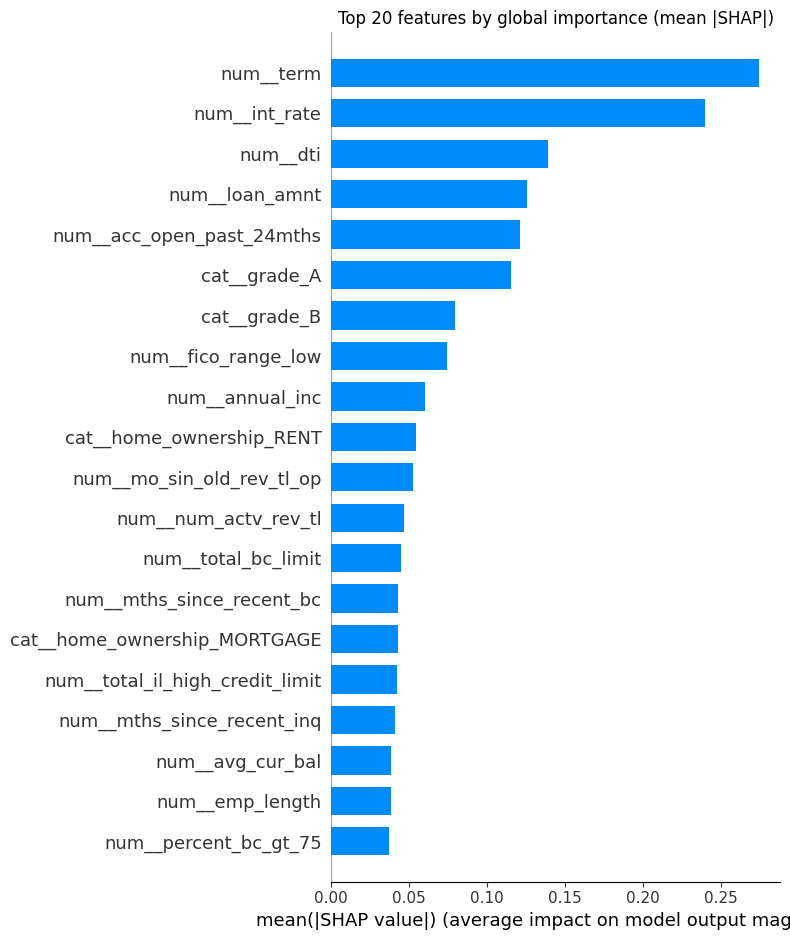

In [8]:
# Bar plot: features ranked by mean absolute SHAP value
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_pos, 
    X_val_sample, 
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Top 20 features by global importance (mean |SHAP|)', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/shap_global_importance.png', dpi=120, bbox_inches='tight')
plt.show()

/var/folders/r_/mwc7qts15xd177svcc33_blr0000gp/T/ipykernel_29200/1328266949.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


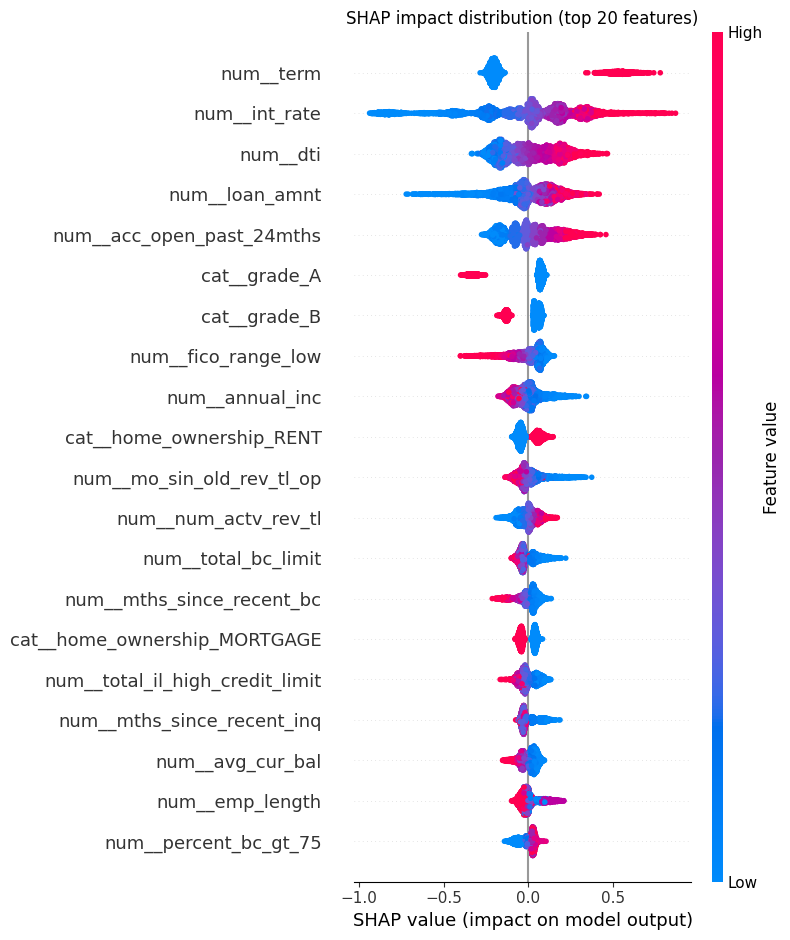

In [9]:
# Beeswarm: how each feature's values affect predictions
fig = plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values_pos,
    X_val_sample,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP impact distribution (top 20 features)', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()


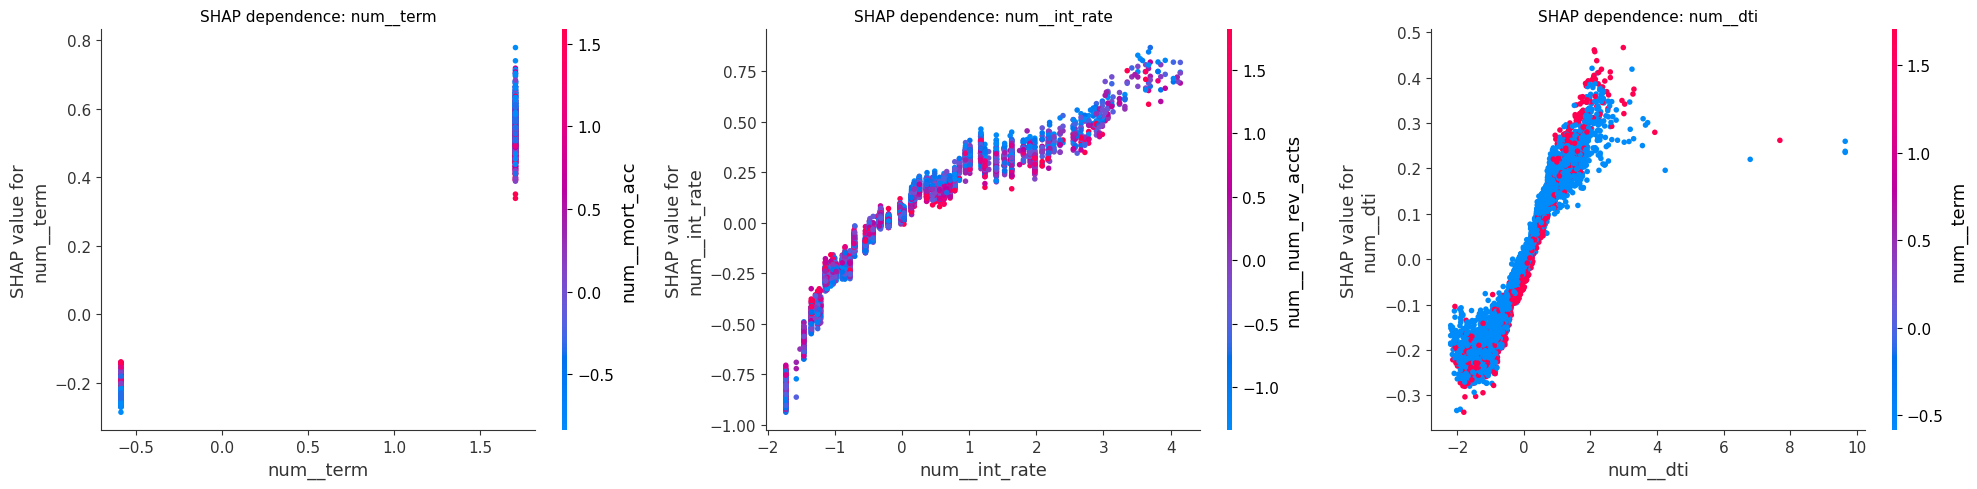

In [10]:
# Build a dataframe from the sample for clean dependence plot indexing
import pandas as pd
X_val_sample_df = pd.DataFrame(X_val_sample, columns=feature_names)

# Top 3 features to investigate
top_features = ['num__term', 'num__int_rate', 'num__dti']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, feature in zip(axes, top_features):
    feature_idx = list(feature_names).index(feature)
    shap.dependence_plot(
        feature_idx,
        shap_values_pos,
        X_val_sample_df,
        feature_names=feature_names,
        ax=ax,
        show=False,
        interaction_index='auto'  # SHAP picks the most interacting feature for color
    )
    ax.set_title(f'SHAP dependence: {feature}', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/shap_dependence_top3.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
# Predict on all val
val_probs_all = base_model.predict_proba(X_val_proc)[:, 1]

# Pick three interesting cases
high_risk_idx = int(np.argmax(val_probs_all))
low_risk_idx  = int(np.argmin(val_probs_all))
borderline_idx = int(np.argmin(np.abs(val_probs_all - best_threshold)))

selected = [
    ('High-risk rejection', high_risk_idx),
    ('Low-risk approval',   low_risk_idx),
    ('Borderline case',     borderline_idx)
]

# Show borrower context using original (unscaled) feature values
for label, idx in selected:
    row = X_val.iloc[idx]
    print(f"\n{'='*60}")
    print(f"  {label}")
    print('='*60)
    print(f"  Predicted P(default): {val_probs_all[idx]:.4f}")
    print(f"  Decision: {'APPROVE' if val_probs_all[idx] < best_threshold else 'REJECT'} (threshold {best_threshold:.4f})")
    print(f"  Actual outcome: {'DEFAULTED' if y_val[idx] else 'PAID'}")
    print(f"  ---")
    print(f"  Loan:     ${row['loan_amnt']:,.0f}, {row['term']} months, {row['int_rate']:.1f}% interest, grade {row['grade']}")
    print(f"  Borrower: ${row['annual_inc']:,.0f}/yr income, DTI {row['dti']:.1f}%, FICO {row['fico_range_low']:.0f}")
    print(f"  Profile:  {row['emp_length']} yrs employed, {row['home_ownership']}, purpose: {row['purpose']}")
    print(f"  History:  {row['acc_open_past_24mths']:.0f} accounts opened past 24mo, {row['mo_sin_old_rev_tl_op']:.0f} mo since oldest tradeline")

/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  High-risk rejection
  Predicted P(default): 0.8787
  Decision: REJECT (threshold 0.1457)
  Actual outcome: DEFAULTED
  ---
  Loan:     $15,425, 60 months, 28.7% interest, grade G
  Borrower: $91,000/yr income, DTI 31.8%, FICO 680
  Profile:  10.0 yrs employed, RENT, purpose: major_purchase
  History:  18 accounts opened past 24mo, 31 mo since oldest tradeline

  Low-risk approval
  Predicted P(default): 0.0070
  Decision: APPROVE (threshold 0.1457)
  Actual outcome: PAID
  ---
  Loan:     $12,000, 36 months, 5.3% interest, grade A
  Borrower: $160,000/yr income, DTI 6.7%, FICO 800
  Profile:  2.0 yrs employed, MORTGAGE, purpose: home_improvement
  History:  4 accounts opened past 24mo, 225 mo since oldest tradeline

  Borderline case
  Predicted P(default): 0.1457
  Decision: REJECT (threshold 0.1457)
  Actual outcome: DEFAULTED
  ---
  Loan:     $30,000, 36 months, 13.4% interest, grade C
  Borrower: $70,000/yr income, DTI 14.4%, FICO 760
  Profile:  10.0 yrs employed, OWN, purpose

/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


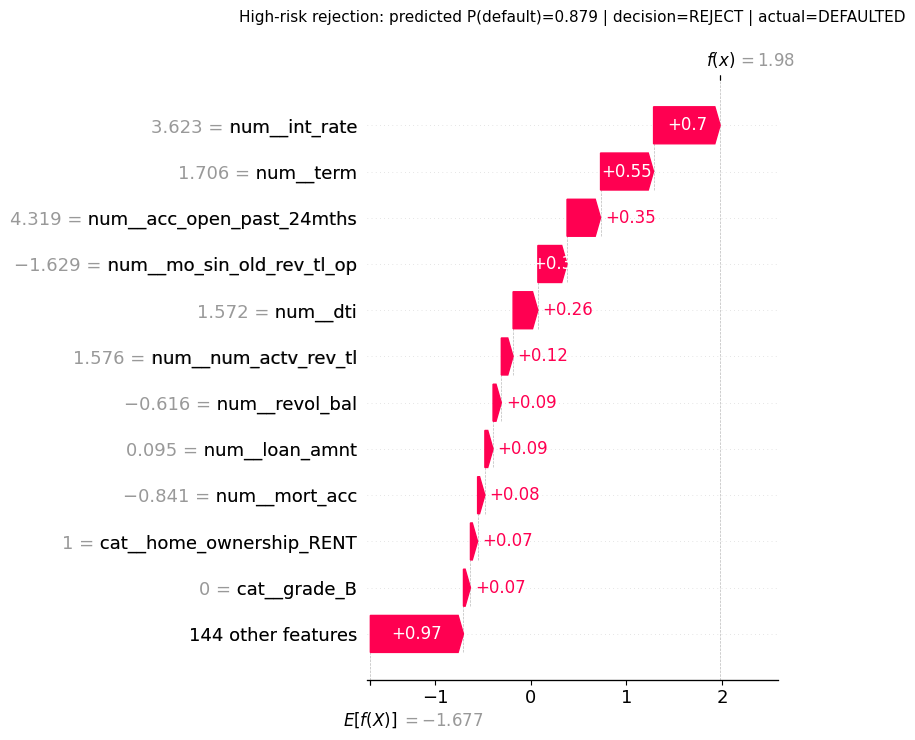

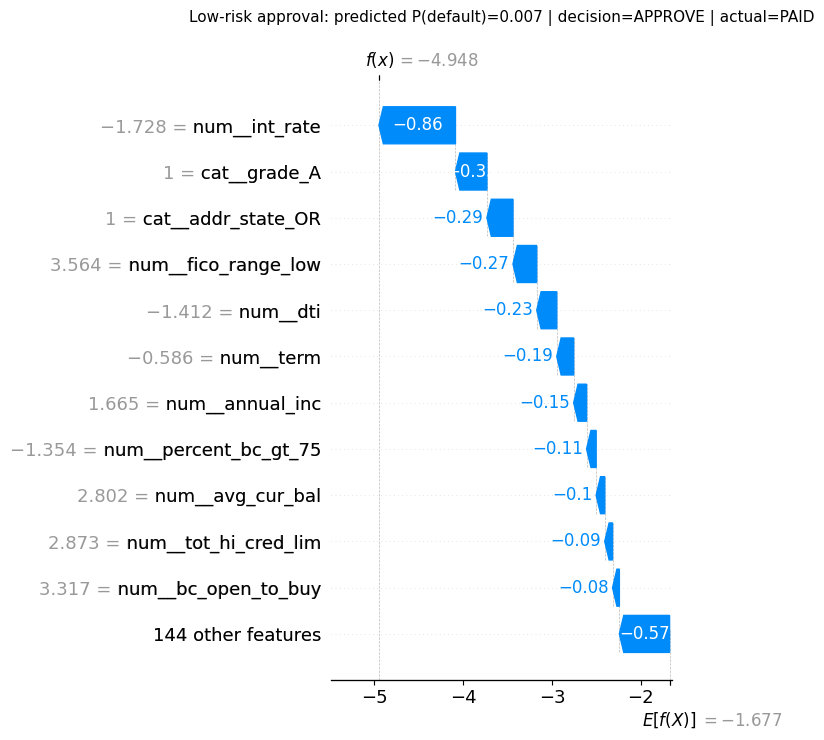

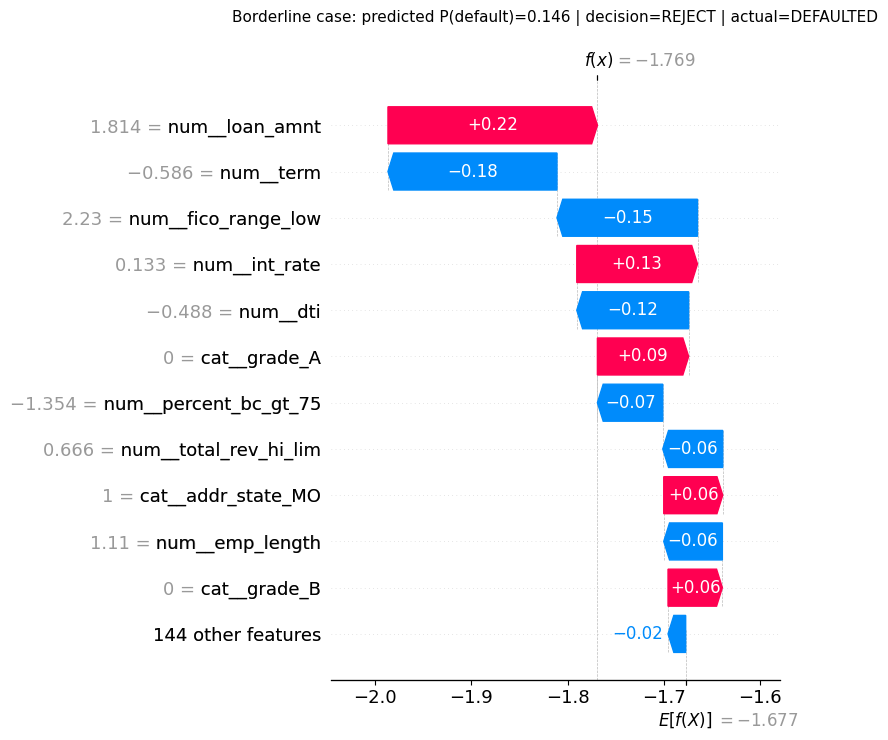

In [12]:
# Compute SHAP for the three specific borrowers
selected_indices = [idx for _, idx in selected]
X_selected = X_val_proc[selected_indices]
shap_values_selected = explainer.shap_values(X_selected)

# Handle SHAP format
if isinstance(shap_values_selected, list):
    shap_values_selected = shap_values_selected[1]

# Get expected value (base prediction)
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(np.atleast_1d(expected_value)) > 1 else float(np.atleast_1d(expected_value)[0])

# Plot each waterfall as a separate figure
for i, (label, idx) in enumerate(selected):
    fig = plt.figure(figsize=(12, 7))
    
    expl = shap.Explanation(
        values=shap_values_selected[i],
        base_values=expected_value,
        data=X_val_proc[idx],
        feature_names=list(feature_names)
    )
    
    shap.plots.waterfall(expl, max_display=12, show=False)
    
    actual = 'DEFAULTED' if y_val[idx] else 'PAID'
    decision = 'REJECT' if val_probs_all[idx] >= best_threshold else 'APPROVE'
    plt.title(
        f'{label}: predicted P(default)={val_probs_all[idx]:.3f} | '
        f'decision={decision} | actual={actual}',
        fontsize=11, pad=20
    )
    plt.tight_layout()
    
    fname = label.lower().replace(' ', '_').replace('-', '_')
    plt.savefig(f'../reports/shap_waterfall_{fname}.png', dpi=120, bbox_inches='tight')
    plt.show()